# Garbage Detection with a Pretrained YOLO Model
### Finding and labeling 7 kinds of waste in photos

This is our first **object detection** project. Earlier projects gave one label per image.
Here an image can have several objects, and for each object we need two answers:
- **What** is it? (the class)
- **Where** is it? (a box around it)

We take a **YOLO** detector that was already trained on the COCO dataset (80 everyday objects)
and fine-tune it on our 7 waste classes:
`Cardboard, Garbage, Glass, Metal, Paper, Plastic, Trash`.

**Dataset:** `dmedhi/garbage-image-classification-detection` on Hugging Face
(about 3,500 images with boxes).

**Plan:**
1. Load the dataset and check how the boxes are stored.
2. Check class balance.
3. Convert the boxes to YOLO's format and save files to disk.
4. Draw the converted boxes to make sure the conversion is correct.
5. Fine-tune `yolo26n.pt` (the nano / smallest YOLO).
6. Read the metrics: precision, recall, mAP.
7. Look at predictions vs. the true boxes.

Run this on Google Colab with a GPU runtime.

## Detection vs classification, in short

```
Classification transfer learning:
    pretrained backbone + a NEW final layer      (1 output: the class)

Detection transfer learning:
    pretrained backbone + a prediction head      (2 outputs at many locations: class AND box)
```

When we load our 7-class `data.yaml`, YOLO changes the class part of its head from
80 classes to 7, and keeps the rest of the pretrained weights as a starting point.

## 1. Setup

We pin `ultralytics==8.4.132` so the commands match the rest of the course.

In [1]:
!pip install -q "ultralytics==8.4.132" datasets

from pathlib import Path
import random
import shutil

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import ultralytics
from ultralytics import YOLO
import yaml

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = 0 if torch.cuda.is_available() else "cpu"  # ultralytics wants a GPU index (int) or "cpu"
print("ultralytics:", ultralytics.__version__)
print("device:", DEVICE)

WORKDIR = Path("/content/garbage_detection")
WORKDIR.mkdir(exist_ok=True, parents=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 5.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
ultralytics: 8.4.132
device: 0


## 2. Load the dataset and check the box format

For detection, always check how the boxes are stored **before** writing any code.
Boxes can be:
- `[x_min, y_min, x_max, y_max]`  (two corners), or
- `[x_min, y_min, width, height]` (one corner + size),
- in pixels, or in fractions from 0 to 1.

A wrong guess produces boxes that still look "almost right", so it is a silent bug.
We check by drawing the same box both ways and seeing which one makes sense.

This dataset uses `[x_min, y_min, width, height]` in pixels.

README.md:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  124MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 15.7MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3094 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/397 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'class_name', 'bbox', 'segmentation'],
        num_rows: 3094
    })
    validation: Dataset({
        features: ['image', 'label', 'class_name', 'bbox', 'segmentation'],
        num_rows: 397
    })
})

keys: ['image', 'label', 'class_name', 'bbox', 'segmentation']
class_name: Trash
bbox (raw): [[186.0, 116.0, 250.5, 386.5]]
image size (w, h): (640, 640)


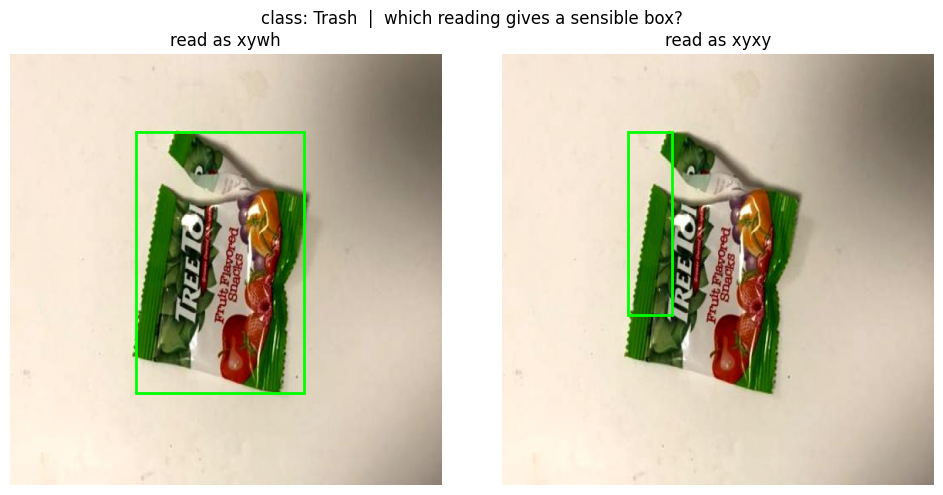

In [2]:
from datasets import load_dataset

raw = load_dataset("dmedhi/garbage-image-classification-detection")
print(raw)

example = raw["train"][0]
print("\nkeys:", list(example.keys()))
print("class_name:", example["class_name"])
print("bbox (raw):", example["bbox"])
print("image size (w, h):", example["image"].size)

# Draw the first box two ways and see which one is a sensible box.
img = example["image"]
box = example["bbox"][0]  # first object in this image
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, mode in zip(axes, ["xywh", "xyxy"]):
    ax.imshow(img)
    if mode == "xywh":
        x, y, w, h = box
    else:
        x, y, x2, y2 = box
        w, h = x2 - x, y2 - y
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="lime", facecolor="none")
    ax.add_patch(rect)
    ax.set_title(f"read as {mode}")
    ax.axis("off")
plt.suptitle(f"class: {example['class_name']}  |  which reading gives a sensible box?")
plt.tight_layout(); plt.show()
# Result: this dataset's bbox is [x_min, y_min, WIDTH, HEIGHT] in pixels.
# Always run a check like this on a new detection dataset - never just assume.

## 3. Class balance

This dataset is uneven: some waste types have many more images than others.
For detection this matters because a rare class gets fewer examples for **both** jobs
(guessing the class and drawing the box). We note it now and check later whether it
actually hurts the score.

classes: ['Cardboard', 'Garbage', 'Glass', 'Metal', 'Paper', 'Plastic', 'Trash']


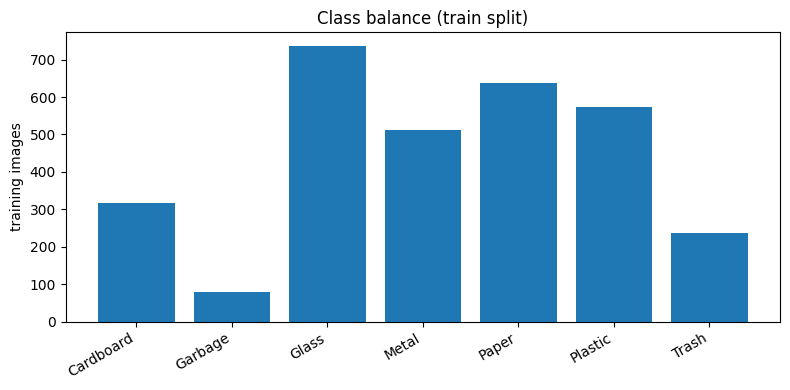

Cardboard : 318
Garbage   : 80
Glass     : 736
Metal     : 512
Paper     : 637
Plastic   : 574
Trash     : 237


In [3]:
from collections import Counter

train_counts = Counter(raw["train"]["class_name"])
class_names = sorted(train_counts.keys())
NUM_CLASSES = len(class_names)
name_to_id = {name: i for i, name in enumerate(class_names)}
print("classes:", class_names)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(class_names, [train_counts[c] for c in class_names])
ax.set_ylabel("training images"); ax.set_title("Class balance (train split)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()
for c in class_names:
    print(f"{c:10s}: {train_counts[c]}")
# "Garbage" has very few images compared to "Glass".
# Expect "Garbage" to have the weakest score in the evaluation later.

## 4. Convert the boxes to YOLO format

YOLO's trainer wants files on disk in this layout:

```
images/train   images/val   images/test
labels/train   labels/val   labels/test
data.yaml
```

Each image has a `.txt` label file. One line per object:

```
<class_id> <x_center> <y_center> <width> <height>
```

All four numbers are **fractions of the image size (0 to 1)**, not pixels.
This way the label stays correct even if the image is resized later.
We also use the box **center** (not a corner), because that is how YOLO's grid works.

So we convert `[x_min, y_min, w, h]` in pixels to `[x_center/W, y_center/H, w/W, h/H]`.

In [4]:
def coco_xywh_abs_to_yolo(bbox, img_w, img_h):
    # pixels [x_min, y_min, w, h]  ->  fractions [x_center, y_center, w, h]
    x_min, y_min, w, h = bbox
    x_center = (x_min + w / 2) / img_w
    y_center = (y_min + h / 2) / img_h
    return x_center, y_center, w / img_w, h / img_h


def export_split(hf_split, split_name, out_root):
    img_dir = out_root / "images" / split_name
    lbl_dir = out_root / "labels" / split_name
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    for i, ex in enumerate(hf_split):
        img = ex["image"].convert("RGB")
        w, h = img.size
        img_path = img_dir / f"{split_name}_{i:05d}.jpg"
        img.save(img_path, quality=95)

        class_id = name_to_id[ex["class_name"]]
        lines = []
        for bbox in ex["bbox"]:
            xc, yc, bw, bh = coco_xywh_abs_to_yolo(bbox, w, h)
            # keep every value inside [0, 1] in case an annotation goes a little past the edge
            xc, yc, bw, bh = (min(max(v, 0.0), 1.0) for v in (xc, yc, bw, bh))
            lines.append(f"{class_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

        (lbl_dir / f"{split_name}_{i:05d}.txt").write_text("\n".join(lines))

    return len(hf_split)


# The dataset has train + validation. We cut a small test set out of validation
# so we still have an untouched set for the final score.
val_split = raw["validation"].train_test_split(test_size=0.4, seed=SEED)
val_ds, test_ds = val_split["train"], val_split["test"]

n_train = export_split(raw["train"], "train", WORKDIR)
n_val   = export_split(val_ds, "val", WORKDIR)
n_test  = export_split(test_ds, "test", WORKDIR)
print(f"exported: train={n_train}  val={n_val}  test={n_test}")

exported: train=3094  val=238  test=159


In [5]:
# data.yaml tells YOLO where each split is and maps class id -> class name.
data_yaml = {
    "path": str(WORKDIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {i: name for i, name in enumerate(class_names)},
}
yaml_path = WORKDIR / "data.yaml"
yaml_path.write_text(yaml.dump(data_yaml, sort_keys=False))
print(yaml_path.read_text())

path: /content/garbage_detection
train: images/train
val: images/val
test: images/test
names:
  0: Cardboard
  1: Garbage
  2: Glass
  3: Metal
  4: Paper
  5: Plastic
  6: Trash



## 5. Check the converted labels

This is the most important check in a detection pipeline. We draw the converted YOLO
labels back on their images. If the conversion math is wrong (swapped axis, wrong
normalization), we see it here, before spending any training on wrong labels.

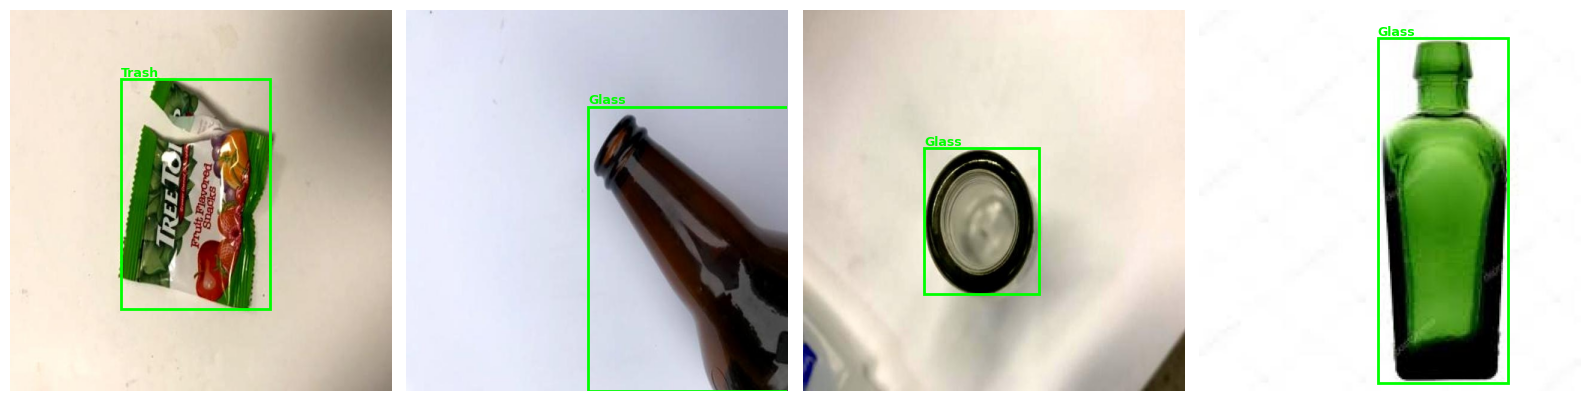

In [6]:
def draw_yolo_labels(img_path, lbl_path, class_names, ax):
    img = plt.imread(img_path)
    h, w = img.shape[:2]
    ax.imshow(img)
    for line in lbl_path.read_text().strip().splitlines():
        cid, xc, yc, bw, bh = (float(v) for v in line.split())
        cid = int(cid)
        # fractions -> pixels, center -> top-left corner
        x = (xc - bw / 2) * w
        y = (yc - bh / 2) * h
        rect = patches.Rectangle((x, y), bw * w, bh * h, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, max(y - 4, 0), class_names[cid], color="lime", fontsize=9, weight="bold")
    ax.axis("off")


sample_imgs = sorted((WORKDIR / "images" / "train").glob("*.jpg"))[:4]
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, img_path in zip(axes, sample_imgs):
    lbl_path = WORKDIR / "labels" / "train" / f"{img_path.stem}.txt"
    draw_yolo_labels(img_path, lbl_path, class_names, ax)
plt.tight_layout(); plt.show()
# If the boxes sit correctly on the objects, the conversion is good and we can train.
# If they look shifted or the wrong size, fix coco_xywh_abs_to_yolo before training.

## 6. About YOLO

YOLO looks at the whole image once and predicts every object's class and box together.
Its parts:

```
INPUT IMAGE
   |
BACKBONE  - conv layers that pull out features, shrinking the image step by step.
   |        Gives 3 feature maps: P3 (small objects), P4 (medium), P5 (large).
   |
NECK      - mixes the 3 feature maps so each one has both fine detail and meaning.
   |
HEAD      - 3 detectors, one per scale. Each has 2 branches:
   |          class branch -> which class (COCO: 80, ours: 7)
   |          box branch   -> x, y, w, h
   |
raw predictions -> keep confident ones + remove duplicate boxes (NMS) -> final boxes
```

We use **nano** (`yolo26n.pt`), the smallest size, because:
- Our dataset is modest (~3,100 training images).
- The waste objects are large and easy to see.
- Nano trains fast, so we can re-run while tuning.

Fine-tuning keeps the backbone and neck (general "what objects look like" knowledge from
COCO) and mostly retrains the class branch for our 7 classes.

## 7. Fine-tune

Nothing is frozen here (detection usually works better when the whole network can adapt).
The pretrained backbone is protected instead by a **learning-rate warmup**: the first few
epochs use a very small learning rate, then it ramps up, so the still-random head does not
send a shock of noisy gradients into the backbone on the first pass.

One training step:

```
1. Take a batch of 16 images + their true boxes.
2. Forward pass: run through backbone -> neck -> head, get predicted classes + boxes.
3. Loss: compare predictions to the true boxes -> 3 numbers (box, cls, dfl).
4. Backward pass: find how each weight affected the loss.
5. Update: nudge each weight to lower the loss.
6. Next batch.
```

One epoch = all batches once. We ask for 50 epochs, but `patience=10` stops early if the
validation score does not improve for 10 epochs in a row.

Settings we use:
- `epochs=50` – a reasonable budget; early stopping handles the rest.
- `imgsz=640` – standard YOLO size; fine here because the objects are large.
- `batch=16` – balance of stable gradients and GPU memory (lower it if you get an out-of-memory error).
- `patience=10` – stop if validation mAP does not improve for 10 epochs.

In [7]:
model = YOLO("yolo26n.pt")   # COCO-pretrained nano model

results = model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    device=DEVICE,
    patience=10,
    seed=SEED,
    project=str(WORKDIR / "runs"),
    name="garbage_yolo_finetune",
    exist_ok=True,
)
# Prints box / cls / dfl losses and validation metrics (precision, recall, mAP50, mAP50-95)
# each epoch, and saves best.pt / last.pt under WORKDIR/runs/garbage_yolo_finetune/weights/.

New https://pypi.org/project/ultralytics/8.4.146 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/garbage_detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mod

## 8. The three loss numbers

Every epoch prints `box_loss`, `cls_loss`, `dfl_loss`:

```
box_loss  - how far the predicted box is from the true box (position and size)
cls_loss  - how wrong the predicted class is
dfl_loss  - how precisely the box edges are placed (a fine adjustment on top of box_loss)
```

All three should go down over the epochs. If one stops improving while the others keep
falling, that tells you which part still needs work (for example, flat `cls_loss` means
the model finds objects well but still confuses their class).

## 9. Evaluate: IoU, precision, recall, mAP

- **IoU** (Intersection over Union) = overlap area / union area, for a predicted box vs a
  true box. A prediction counts as correct only if its IoU passes a threshold (usually 0.5).
- **Precision** = of the boxes the model predicted, how many were right.
  Low precision = too many false alarms.
- **Recall** = of the real objects, how many the model found.
  Low recall = it misses real objects.
- **mAP50** = average precision across classes at IoU 0.5 (lenient).
- **mAP50-95** = the same, averaged over IoU 0.5 to 0.95 (strict; also rewards tight boxes).

A high mAP50 but a low mAP50-95 means: the model finds the right objects, but its boxes
are not tight.

Small example: 20 real Glass objects. The model gets 16 right, misses 4, and adds 3
wrong "Glass" boxes.

```
precision = 16 / (16 + 3) = 0.84
recall    = 16 / (16 + 4) = 0.80
```

In [8]:
metrics = model.val(data=str(yaml_path), split="test", imgsz=640, device=DEVICE)

print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mean precision: {metrics.box.mp:.4f}")
print(f"mean recall:    {metrics.box.mr:.4f}")

print("\nPer-class AP50:")
for i, name in enumerate(class_names):
    print(f"  {name:10s}: {metrics.box.ap50[i]:.4f}")
# Compare this table to the class-balance chart from step 3.
# "Garbage" (the rarest class) is likely the lowest here. If so, that is a DATA problem
# (add more Garbage images), not a training problem.

Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1358.3±395.0 MB/s, size: 63.6 KB)
val: Scanning /content/garbage_detection/labels/test... 159 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 159/159 2.2Kit/s 0.1s
val: New cache created: /content/garbage_detection/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.5it/s 2.9s
                   all        159        250      0.714      0.601      0.672      0.562
             Cardboard         15         22      0.781      0.682      0.712      0.576
               Garbage          3         17      0.771      0.397      0.444       0.34
                 Glass         47         69      0.839      0.754      0.843      0.727
                 Metal         26         38      0.641      0.

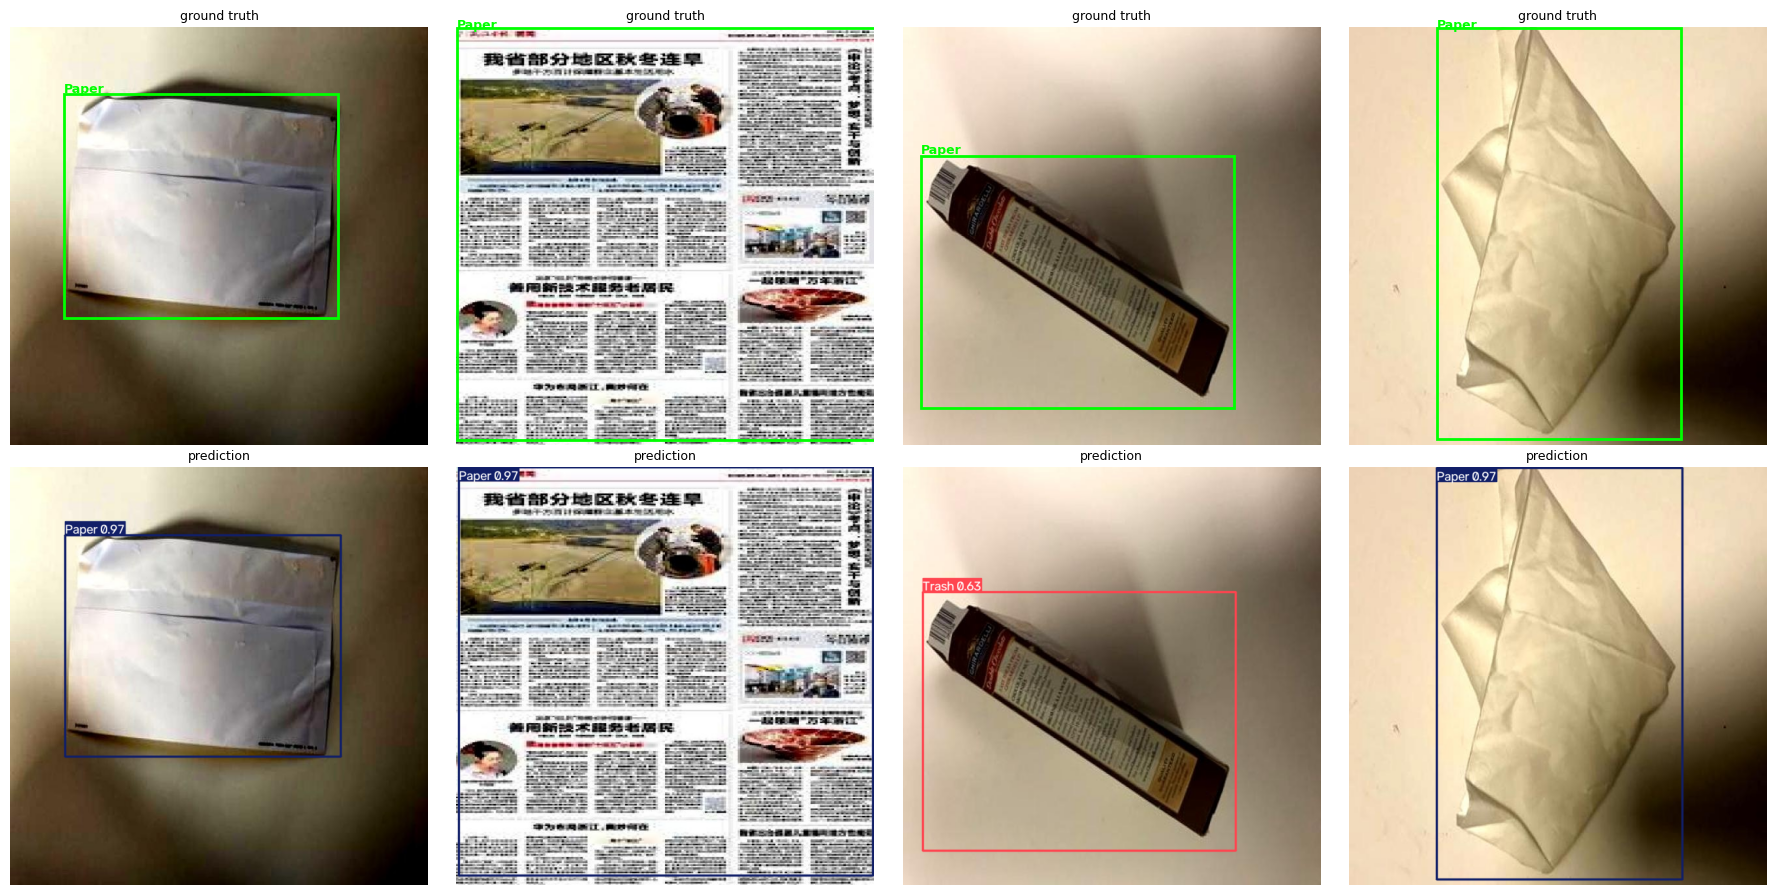

In [9]:
# Run the model on a few test images and show prediction vs. ground truth side by side.
test_imgs = sorted((WORKDIR / "images" / "test").glob("*.jpg"))[:4]
pred_results = model.predict(source=[str(p) for p in test_imgs], conf=0.25, imgsz=640,
                             device=DEVICE, verbose=False)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for col, (img_path, pred) in enumerate(zip(test_imgs, pred_results)):
    lbl_path = WORKDIR / "labels" / "test" / f"{img_path.stem}.txt"
    draw_yolo_labels(img_path, lbl_path, class_names, axes[0, col])
    axes[0, col].set_title("ground truth", fontsize=9)

    axes[1, col].imshow(pred.plot()[:, :, ::-1])  # pred.plot() is BGR, flip to RGB
    axes[1, col].set_title("prediction", fontsize=9)
    axes[1, col].axis("off")
plt.tight_layout(); plt.show()
# Look for three different kinds of mistake:
#   - false positive: a predicted box with no real object there
#   - false negative: a real object the model missed
#   - loose box: right class, but the box is offset or too big
# Each one has a different fix (confidence threshold / more data / more training or higher resolution).

## 10. Experiments to try

Change only **one** thing per run, predict what will happen, then check the number.

```
BASELINE: yolo26n.pt, epochs=50, imgsz=640, batch=16, default augmentation
  record: mAP50, mAP50-95, per-class AP50 (especially "Garbage")

1. Fix the imbalance
   Change:  duplicate every "Garbage" image + label 3-4x in the train folder before training
   Expect:  "Garbage" AP50 goes up, other classes stay about the same
   Check:   the "Garbage" row in the per-class AP50 table

2. Bigger model
   Change:  swap yolo26n.pt for yolo26s.pt, nothing else
   Expect:  small mAP50-95 gain, slower training - is it worth it?
   Check:   mAP50-95 and training speed per epoch

3. Train longer
   Change:  epochs=100 (patience still 10)
   Expect:  if it already converged, it stops near the same epoch; if not, mAP keeps rising
   Check:   the epoch where each run stopped, and final mAP50-95

4. Freeze the backbone
   Change:  add freeze=10 to model.train(...)
   Expect:  faster training, but usually a bit lower final mAP
   Check:   final mAP50-95 and wall-clock training length

5. Confidence threshold
   Change:  model.val(..., conf=0.1)  vs  conf=0.7
   Expect:  low threshold -> higher recall, lower precision; high threshold -> the reverse
   Check:   mean precision and mean recall at each setting
```
